# Immune-repertoire analysis with `ov.airr`

`omicverse.airr` is a unified framework for adaptive immune receptor
repertoire sequencing (AIRR-seq: TCR / BCR). This notebook is an end-to-end
tour:

1. **Single-cell TCR/BCR** — load a dataset, chain QC, clonotype definition,
   clonal expansion, clonotype network, diversity, repertoire overlap and
   V(D)J usage (a clean AnnData-native reimplementation of scirpy's core).
2. **Bulk repertoire** — diversity, overlap and clonality via the
   `pyimmunarch` backend.
3. **B-cell analysis** — somatic-hypermutation properties and clonal
   clustering via the Immcantation backends (`pyshazam`, `pyscoper`,
   `pyalakazam`).

All data is generated or bundled — no external download is needed.

## 1. Single-cell AIRR analysis

### 1.1 Load / simulate a single-cell dataset

`ov.airr` reads 10x Cell Ranger V(D)J output
(`ov.airr.read_10x_vdj`) or AIRR rearrangement TSVs (`ov.airr.read_airr`).
Here we simulate a small single-cell TCR dataset with known clonotype
structure so the notebook is fully self-contained.

In [1]:
import omicverse as ov

adata = ov.airr.simulate_airr(n_cells=400, n_clones=50, receptor='TCR', seed=0)
adata

AnnData object with n_obs × n_vars = 400 × 1
    obs: 'has_ir', 'receptor_type', 'VJ_1_v_gene', 'VJ_1_d_gene', 'VJ_1_j_gene', 'VJ_1_c_gene', 'VJ_1_junction', 'VJ_1_junction_aa', 'VJ_1_locus', 'VJ_1_duplicate_count', 'VJ_1_productive', 'VJ_2_v_gene', 'VJ_2_d_gene', 'VJ_2_j_gene', 'VJ_2_c_gene', 'VJ_2_junction', 'VJ_2_junction_aa', 'VJ_2_locus', 'VJ_2_duplicate_count', 'VJ_2_productive', 'VDJ_1_v_gene', 'VDJ_1_d_gene', 'VDJ_1_j_gene', 'VDJ_1_c_gene', 'VDJ_1_junction', 'VDJ_1_junction_aa', 'VDJ_1_locus', 'VDJ_1_duplicate_count', 'VDJ_1_productive', 'VDJ_2_v_gene', 'VDJ_2_d_gene', 'VDJ_2_j_gene', 'VDJ_2_c_gene', 'VDJ_2_junction', 'VDJ_2_junction_aa', 'VDJ_2_locus', 'VDJ_2_duplicate_count', 'VDJ_2_productive', 'group', 'sample'
    uns: 'airr_contigs'

In [2]:
# the per-cell receptor data lives in obs (VJ_1 / VDJ_1 chain slots)
adata.obs[['VJ_1_v_gene', 'VJ_1_junction_aa',
           'VDJ_1_v_gene', 'VDJ_1_junction_aa', 'receptor_type']].head()

,VJ_1_v_gene,VJ_1_junction_aa,VDJ_1_v_gene,VDJ_1_junction_aa,receptor_type
cell_id,,,,,
CELL00000-1,TRAV14,IRYQDQRQDNI,TRBV6,DYQTAKEWKQI,TCR
CELL00001-1,TRAV2,KAMSRYMNYHSE,TRBV20,IQNEQNWPVYCC,TCR
CELL00002-1,TRAV12,GAETCHLQPWQ,TRBV16,GAYTAADALLR,TCR
CELL00003-1,TRAV10,CAETPWMPYRPMNWGT,TRBV6,QAIVNASRTECVAMCG,TCR
CELL00004-1,TRAV10,CAETPWMPYRPMNWGT,TRBV6,QAIVNASRTECVAMCG,TCR


### 1.2 Chain QC

`chain_qc` classifies each cell by its TCR/BCR chain configuration —
`single pair`, `orphan VJ/VDJ`, `multichain` or `no IR`.

In [3]:
ov.airr.chain_qc(adata)
adata.obs['chain_pairing'].value_counts()

chain_pairing
single pair    400
Name: count, dtype: int64

### 1.3 Clonotype definition

`define_clonotypes` groups cells with identical CDR3 sequences into exact
clonotypes; `define_clonotype_clusters` merges similar receptors within a
CDR3 distance cutoff.

In [4]:
ov.airr.define_clonotypes(adata)
adata.uns['clonotype']

{'sequence': 'aa', 'n_clonotypes': 42, 'key': 'clone_id'}

In [5]:
ov.airr.define_clonotype_clusters(adata, metric='hamming', cutoff=2)
adata.uns['clonotype_clusters']

{'metric': 'hamming',
 'cutoff': 2,
 'sequence': 'aa',
 'n_clusters': 42,
 'key': 'cc_clone_id'}

### 1.4 Clonal expansion

`clonal_expansion` buckets every cell by the size of the clonotype it
belongs to.

In [6]:
ov.airr.clonal_expansion(adata)
adata.obs['clonal_expansion'].value_counts()

clonal_expansion
>= 4          366
3              18
2               8
1 (single)      8
Name: count, dtype: int64

<Axes: title={'center': 'Clonal expansion'}, xlabel='group', ylabel='fraction of cells'>

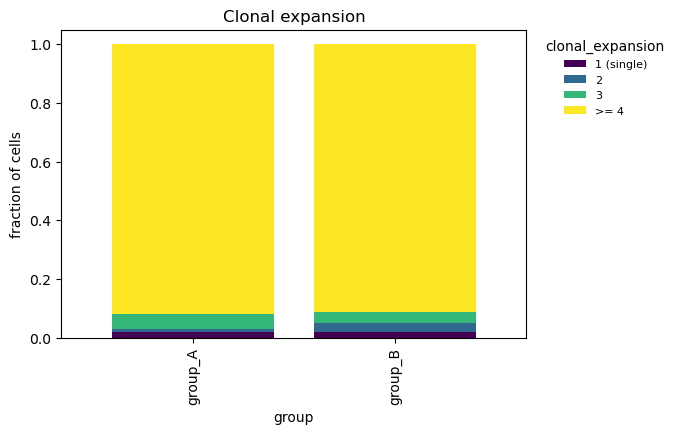

In [7]:
ov.airr.clonal_expansion_plot(adata, groupby='group')

### 1.5 Clonotype network

`clonotype_network` lays out the clonotype graph in 2-D; nodes are cells,
edges connect cells within a CDR3 distance cutoff.

<Axes: title={'center': 'Clonotype network'}>

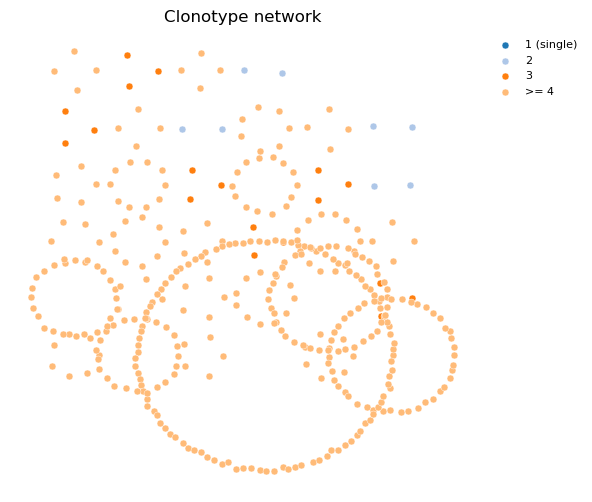

In [8]:
ov.airr.clonotype_network(adata, min_cells=2)
ov.airr.clonotype_network_plot(adata, color='clonal_expansion')

### 1.6 Diversity & repertoire overlap

`alpha_diversity` summarises the clonotype distribution per group;
`repertoire_overlap` measures how clonotypes are shared between samples.

In [9]:
div = ov.airr.alpha_diversity(adata, groupby='sample', metric='shannon')
div

,n_cells,n_clonotypes,shannon
group,,,
s1,91,27,2.677024
s2,96,31,2.892550
s3,104,28,2.741760
s4,109,25,2.562662


<Axes: title={'center': 'Repertoire overlap (jaccard)'}>

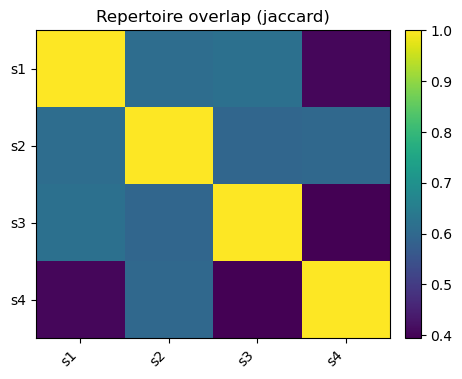

In [10]:
ov.airr.repertoire_overlap_plot(adata, groupby='sample', metric='jaccard')

### 1.7 V(D)J gene usage & spectratype

`vdj_usage` gives V/D/J segment usage frequencies; `spectratype` gives the
CDR3-length distribution.

<Axes: title={'center': 'V gene usage (VDJ_1)'}, xlabel='V gene', ylabel='usage frequency'>

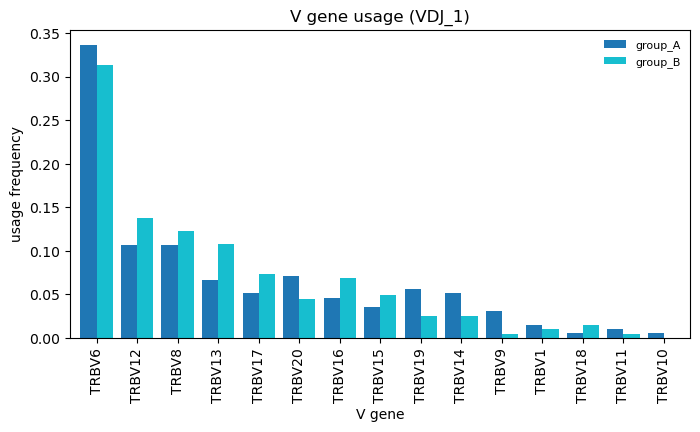

In [11]:
ov.airr.vdj_usage_plot(adata, gene='v', chain='VDJ_1', groupby='group')

<Axes: title={'center': 'Spectratype (VDJ_1)'}, xlabel='CDR3 length', ylabel='n cells'>

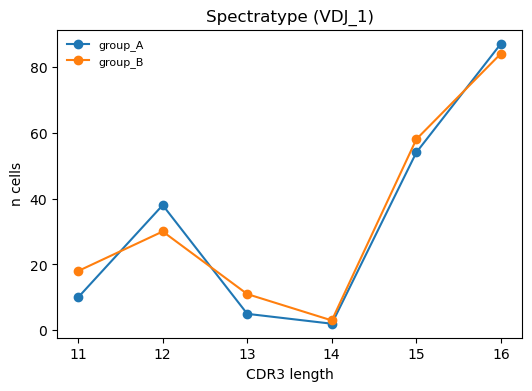

In [12]:
ov.airr.spectratype_plot(adata, groupby='group', chain='VDJ_1')

## 2. Bulk repertoire analysis (`pyimmunarch`)

The bulk side works on the immunarch data model — a set of per-sample
repertoire tables. `simulate_immdata` builds a small cohort for the tour.

In [13]:
immdata = ov.airr.simulate_immdata(n_samples=6, n_clones=200,
                                   receptor='TCR', seed=0)
len(immdata.data), list(immdata.data.keys())

(6, ['sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5', 'sample_6'])

In [14]:
# bulk diversity — Chao1 richness estimator
ov.airr.repertoire_diversity(immdata, method='chao1')

,Estimator,SD,Conf.95.lo,Conf.95.hi
sample_1,168.991813,15.423799,149.556974,214.373871
sample_2,209.067758,30.621527,174.891651,308.526062
sample_3,277.971797,74.626149,186.846406,503.362662
sample_4,493.935112,363.465717,216.613964,2040.056618
sample_5,378.951643,101.201368,249.574300,673.119657
sample_6,106.492865,18.597530,88.527172,173.908177


In [15]:
# bulk repertoire overlap matrix
ov.airr.repertoire_overlap_bulk(immdata, method='jaccard')

,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6
sample_1,NaN,0.569892,0.477273,0.572973,0.563536,0.356250
sample_2,0.569892,NaN,0.492063,0.656085,0.605263,0.373563
sample_3,0.477273,0.492063,NaN,0.535519,0.568966,0.277778
sample_4,0.572973,0.656085,0.535519,NaN,0.608466,0.360000
sample_5,0.563536,0.605263,0.568966,0.608466,NaN,0.369048
sample_6,0.356250,0.373563,0.277778,0.360000,0.369048,NaN


In [16]:
# clonal-space homeostasis
ov.airr.clonality(immdata, method='homeo')

,Rare (0 < X <= 1e-05),Small (1e-05 < X <= 1e-04),Medium (1e-04 < X <= 1e-03),Large (1e-03 < X <= 1e-02),Hyperexpanded (1e-02 < X <= 1)
sample_1,0.0,0.0,0.035878,0.160607,0.803516
sample_2,0.0,0.0,0.017344,0.350478,0.632177
sample_3,0.0,0.0,0.007373,0.289401,0.703226
sample_4,0.0,0.0,0.035515,0.248416,0.716068
sample_5,0.0,0.0,0.014444,0.272347,0.713209
sample_6,0.0,0.0,0.009901,0.142982,0.847117


## 3. B-cell analysis (Immcantation backends)

### 3.1 Clonal clustering (`pyscoper`)

`clonal_clustering` partitions BCR sequences into clones — `identical`,
`hierarchical` or `spectral`.

In [17]:
import pyscoper

bcr_db = pyscoper.load_example_db()
bcr_db.shape

(2000, 16)

In [18]:
clones = ov.airr.clonal_clustering(bcr_db, method='identical')
clones['clone_id'].nunique()

1199

### 3.2 Somatic hypermutation — CDR3 properties (`pyalakazam`)

`aa_properties` computes per-sequence CDR3 amino-acid physicochemical
descriptors.

In [19]:
import pyalakazam

shm_db = pyalakazam.load_example_db()
props = ov.airr.aa_properties(shm_db, seq='junction')
props[['junction_aa_length', 'junction_aa_gravy',
       'junction_aa_charge']].describe().round(3)

,junction_aa_length,junction_aa_gravy,junction_aa_charge
count,1999.000,1999.000,1999.000
mean,21.626,-0.369,-0.557
std,4.068,0.424,1.432
min,7.000,-1.688,-5.855
25%,20.000,-0.636,-1.235
50%,20.000,-0.371,-0.083
75%,25.000,-0.096,-0.073
max,37.000,1.194,5.920


### 3.3 Distance-to-nearest threshold (`pyshazam`)

`distance_threshold` computes the distance-to-nearest distribution and an
automatic clonal-clustering threshold.

In [20]:
threshold, db_dist = ov.airr.distance_threshold(bcr_db)
print('inferred clonal threshold:', round(threshold, 4))

inferred clonal threshold: 0.1738


## Summary

`ov.airr` threads single-cell TCR/BCR analysis, bulk repertoire analytics
and B-cell somatic-hypermutation / clonal analysis behind one registered,
`method=`-dispatch API — discover every function with
`ov.search('immune repertoire')` or browse `ov.airr.__all__`.

In [21]:
len([f for f in ov.airr.__all__ if f not in ('io', 'plotting')])

43